# **Bioinformatics Project - Computational Drug Discovery [Part 4] Regression Models with Random Forest**


## **1. Import libraries**

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## **2. Load the data set**

In [5]:
df = pd.read_csv('CORONA_bioactivity_data_3class_pIC50_pubchem_fp.csv')

### **3.1. Input features**

In [6]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
72,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
73,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
74,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### **3.2. Output features**

In [7]:
Y = df.pIC50
Y

,pIC50
0,4.869666
1,4.882397
2,6.008774
3,6.022276
4,4.950782
...,...
71,6.045757
72,4.920819
73,4.886057
74,4.886057


### **3.3. Let's examine the data dimension**

In [8]:
X.shape

(76, 881)

In [9]:
Y.shape

(76,)

### **3.4. Remove low variance features**

In [10]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [11]:
X.shape

(76, 173)

## **4. Data split (80/20 ratio)**

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [13]:
X_train.shape, Y_train.shape

((60, 173), (60,))

In [14]:
X_test.shape, Y_test.shape

((16, 173), (16,))

## **5. Building a Regression Model using Random Forest**

In [15]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.7705562850776726

In [16]:
Y_pred = model.predict(X_test)

## **6. Scatter Plot of Experimental vs Predicted pIC50 Values**

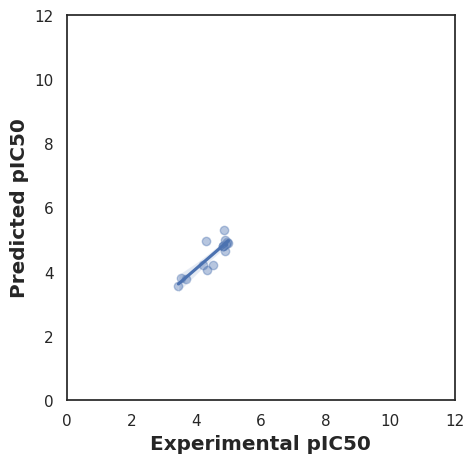

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()